In [1]:
import json
!pip install vaderSentiment
from google.colab import drive
drive.mount('/content/drive')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 2.6 MB/s eta 0:00:00
Mounted at /content/drive


In [2]:
file = "/content/drive/MyDrive/Code/Video_Games.jsonl"
import numpy as np
import json
from collections import defaultdict

NUM_REVIEWS = 5000
IMPORTANT_WORDS = 500
MAX_PER_CLASS = 1000  # 200 per rating = 1000 total balanced

# load equal amounts of each rating
ratings_per_class = defaultdict(list)

with open(file, 'r') as fp:
    for line in fp:
        data = json.loads(line.strip())
        rating = data['rating']
        if len(ratings_per_class[rating]) < MAX_PER_CLASS:
            ratings_per_class[rating].append(data)
        if all(len(v) == MAX_PER_CLASS for v in ratings_per_class.values()):
            break

# flatten into ratings and y lists
ratings = []
y = []

for rating, reviews in ratings_per_class.items():
    for review in reviews:
        ratings.append(review['text'])
        y.append(review['rating'])

y = np.array(y)
X = np.zeros((NUM_REVIEWS, 5))

print(f"Total reviews: {NUM_REVIEWS}")
print(f"Class distribution: {dict(zip(*np.unique(y, return_counts=True)))}")

for review in ratings[:10]:
    print(review)
    print()

Total reviews: 5000
Class distribution: {np.float64(1.0): np.int64(1000), np.float64(2.0): np.int64(1000), np.float64(3.0): np.int64(1000), np.float64(4.0): np.int64(1000), np.float64(5.0): np.int64(1000)}
I’m playing on ps5 and it’s interesting.  It’s unique, massive, and has a neat story.  People are freaking out angry about this game.  I don’t think it’s a top 10 game but it’s definitely a good game on ps5 (played at launch).

good, a tad bit too bulky, but good. they stay on. good texture too.

I really like how consistent the bright was is throughout. The size is perfect. My only complaint is the thread they used to hold the light bar around the outside of the pad is very rough. Because of the side my forearm sits on it, and it gets irritated sometimes in long gaming sessions. I have found if I put a washcloth, or other mousepad over it if I am planning to be playing a while its better. But this covers the lighting and is not really as aesthetically. pleasing. So 4 stars.

This is

In [3]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
import re

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [4]:
# remove basic words with no meaning

stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = re.sub(r'<.*?>', '', text)      # remove html tags like <br/>
    text = re.sub(r'[^a-zA-Z\s]', '', text) # remove punctuation
    words = text.lower().split()                          # lowercase and split
    words = [w for w in words if w not in stop_words]    # remove stopwords
    return ' '.join(words)

# apply ratings list
ratings = [clean_text(r) for r in ratings]

for review in ratings[:10]:
    print(review)
    print()

im playing ps interesting unique massive neat story people freaking angry game dont think top game definitely good game ps played launch

good tad bit bulky good stay good texture

really like consistent bright throughout size perfect complaint thread used hold light bar around outside pad rough side forearm sits gets irritated sometimes long gaming sessions found put washcloth mousepad planning playing better covers lighting really aesthetically pleasing stars

pretty comfortable seems job well band adjusts easily seems hold headset place well even beat saber fit xrnot sure longevity bit expensive considering dont get additional foam doesnt seem options replace hoping seller stands behind product event foam doesnt last long

see pics vive das rubber insulators controllers hold everything seem bit organized sitting deskbut im sure really much opening space wasnt already availablei use alien tape bottom could edge mount desk make really worth italso piece headset rests close controller 

In [5]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
analyzer = SentimentIntensityAnalyzer()

for i, review in enumerate(ratings):
    scores = analyzer.polarity_scores(review)
    X[i, 0] = scores['compound']
    X[i, 1] = scores['pos']
    X[i, 2] = scores['neg']
    X[i, 3] = scores['neu']

print(X.shape)
print(y.shape)
print("compound ,  pos ,  neg ,   neu ,   tf-idf")
# the features used to predict review ratings are compound, pos, neg, neu, and TF-IDF.
# compound is the overall sentiment score ranging from -1 (most negative) to +1 (most positive).
# pos, neg, and neu represent the proportion of the review that is positive, negative, and neutral.
# TF-IDF measures how important each word is based on how unique and frequent it appears across all reviews.
print(X[:20])
print("labels")
print(y[:20])


unique, counts = np.unique(y, return_counts=True)
print(dict(zip(unique, counts)))

(5000, 5)
(5000,)
compound ,  pos ,  neg ,   neu ,   tf-idf
[[0.7788 0.428  0.213  0.359  0.    ]
 [0.8271 0.635  0.     0.365  0.    ]
 [0.9159 0.333  0.096  0.572  0.    ]
 [0.9565 0.385  0.     0.615  0.    ]
 [0.7841 0.156  0.     0.844  0.    ]
 [0.9246 0.489  0.05   0.461  0.    ]
 [0.9231 0.565  0.     0.435  0.    ]
 [0.     0.     0.     1.     0.    ]
 [0.8519 0.806  0.     0.194  0.    ]
 [0.4404 0.744  0.     0.256  0.    ]
 [0.     0.     0.     1.     0.    ]
 [0.6605 0.73   0.     0.27   0.    ]
 [0.6597 0.73   0.     0.27   0.    ]
 [0.7867 0.218  0.044  0.738  0.    ]
 [0.     0.     0.     1.     0.    ]
 [0.4215 0.318  0.     0.682  0.    ]
 [0.     0.     0.     1.     0.    ]
 [0.7506 0.277  0.089  0.635  0.    ]
 [0.8059 0.241  0.088  0.671  0.    ]
 [0.9971 0.223  0.087  0.69   0.    ]]
labels
[4. 4. 4. 4. 4. 4. 4. 4. 4. 4. 4. 4. 4. 4. 4. 4. 4. 4. 4. 4.]
{np.float64(1.0): np.int64(1000), np.float64(2.0): np.int64(1000), np.float64(3.0): np.int64(1000), np.float64

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer
import scipy.sparse as sp



tfidf = TfidfVectorizer(max_features=500) # number of important words to keep
tfidf_features = tfidf.fit_transform(ratings)


X_combined = np.hstack([X[:, :4], tfidf_features.toarray()])

print(X_combined.shape)
print("compound ,  pos ,  neg ,   neu , tf-idf")
print(X_combined[:10])




(5000, 504)
compound ,  pos ,  neg ,   neu , tf-idf
[[0.7788 0.428  0.213  ... 0.     0.     0.    ]
 [0.8271 0.635  0.     ... 0.     0.     0.    ]
 [0.9159 0.333  0.096  ... 0.     0.     0.    ]
 ...
 [0.     0.     0.     ... 0.     0.     0.    ]
 [0.8519 0.806  0.     ... 0.     0.     0.    ]
 [0.4404 0.744  0.     ... 0.     0.     0.    ]]


In [7]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import accuracy_score

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_combined, y, test_size=0.2, random_state=42)

# grid search parameters
param_grid = {'C': [0.1, 1, 10], 'gamma': [0.1, 1, 10]}

# grid search with inner cross validation (cv=5)
grid_search = GridSearchCV(SVC(kernel='rbf', class_weight='balanced'), param_grid, cv=5)

# nested cross validation (outer loop)
scores = cross_val_score(grid_search, X_train, y_train, cv=5)

# fit on training data only
grid_search.fit(X_train, y_train)

# predict on test data
predictions_test = grid_search.predict(X_test)



In [9]:

# test some reviews
review_index = 0

prediction = grid_search.predict(X_combined[review_index:review_index+1])

print(f"Review: {ratings[review_index]}")
print(f"Predicted rating: {prediction[0]}")
print(f"Actual rating: {y[review_index]}")

prediction = grid_search.predict(X_combined[review_index:review_index+1])

review_index = 1
print(f"Review: {ratings[review_index]}")
print(f"Predicted rating: {prediction[0]}")
print(f"Actual rating: {y[review_index]}")

review_index = 2
print(f"Review: {ratings[review_index]}")
print(f"Predicted rating: {prediction[0]}")
print(f"Actual rating: {y[review_index]}")

review_index = 3
print(f"Review: {ratings[review_index]}")
print(f"Predicted rating: {prediction[0]}")
print(f"Actual rating: {y[review_index]}")

review_index = 4
print(f"Review: {ratings[review_index]}")
print(f"Predicted rating: {prediction[0]}")
print(f"Actual rating: {y[review_index]}")

review_index = 5
print(f"Review: {ratings[review_index]}")
print(f"Predicted rating: {prediction[0]}")
print(f"Actual rating: {y[review_index]}")

Review: im playing ps interesting unique massive neat story people freaking angry game dont think top game definitely good game ps played launch
Predicted rating: 4.0
Actual rating: 4.0
Review: good tad bit bulky good stay good texture
Predicted rating: 4.0
Actual rating: 4.0
Review: really like consistent bright throughout size perfect complaint thread used hold light bar around outside pad rough side forearm sits gets irritated sometimes long gaming sessions found put washcloth mousepad planning playing better covers lighting really aesthetically pleasing stars
Predicted rating: 4.0
Actual rating: 4.0
Review: pretty comfortable seems job well band adjusts easily seems hold headset place well even beat saber fit xrnot sure longevity bit expensive considering dont get additional foam doesnt seem options replace hoping seller stands behind product event foam doesnt last long
Predicted rating: 4.0
Actual rating: 4.0
Review: see pics vive das rubber insulators controllers hold everything 

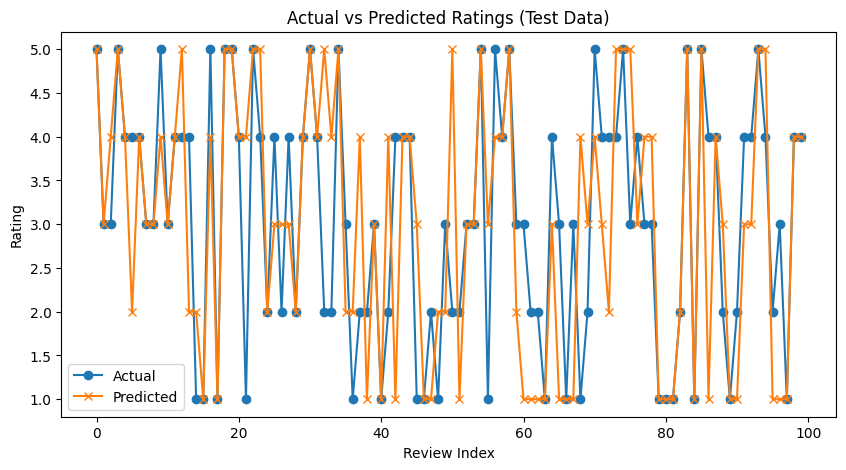

Unseen data accuracy: 0.428
Seen data accuracy: 0.463
Best params: {'C': 1, 'gamma': 1}
# of important words used: 500
# of reviews used : 5000
Unique predictions: [1. 2. 3. 4. 5.]


In [10]:
import matplotlib.pyplot as plt

# get predictions on test data
predictions_test = grid_search.predict(X_test)

# plot
plt.figure(figsize=(10, 5))
plt.plot(y_test[:100], label='Actual', marker='o')
plt.plot(predictions_test[:100], label='Predicted', marker='x')
plt.xlabel('Review Index')
plt.ylabel('Rating')
plt.title('Actual vs Predicted Ratings (Test Data)')
plt.legend()
plt.show()

print(f"Unseen data accuracy: {scores.mean():.3f}")
print(f"Seen data accuracy: {accuracy_score(y_test, predictions_test):.3f}")
print(f"Best params: {grid_search.best_params_}")
print(f"# of important words used: {IMPORTANT_WORDS}")
print(f"# of reviews used : {NUM_REVIEWS}")
print(f"Unique predictions: {np.unique(predictions_test)}")
